In [4]:
%load_ext autoreload
%autoreload 2
import os
import pandas as pd
import numpy as np
import edhec_risk_kit as erk
import matplotlib.pyplot as plt
from scipy.stats import norm

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
ind = erk.get_ind30_returns()
ind.head()

,Food,Beer,Smoke,Games,Books,Hshld,Clths,Hlth,Chems,Txtls,...,Telcm,Servs,BusEq,Paper,Trans,Whlsl,Rtail,Meals,Fin,Other
1926-07,0.0056,-0.0519,0.0129,0.0293,0.1097,-0.0048,0.0808,0.0177,0.0814,0.0039,...,0.0083,0.0922,0.0206,0.0770,0.0193,-0.2379,0.0007,0.0187,0.0037,0.0520
1926-08,0.0259,0.2703,0.0650,0.0055,0.1001,-0.0358,-0.0251,0.0425,0.0550,0.0814,...,0.0217,0.0202,0.0439,-0.0238,0.0488,0.0539,-0.0075,-0.0013,0.0446,0.0676
1926-09,0.0116,0.0402,0.0126,0.0658,-0.0099,0.0073,-0.0051,0.0069,0.0533,0.0231,...,0.0241,0.0225,0.0019,-0.0554,0.0005,-0.0787,0.0025,-0.0056,-0.0123,-0.0386
1926-10,-0.0306,-0.0331,0.0106,-0.0476,0.0947,-0.0468,0.0012,-0.0057,-0.0476,0.0100,...,-0.0011,-0.0200,-0.0109,-0.0508,-0.0264,-0.1538,-0.0220,-0.0411,-0.0516,-0.0849
1926-11,0.0635,0.0729,0.0455,0.0166,-0.0580,-0.0054,0.0187,0.0542,0.0520,0.0311,...,0.0163,0.0377,0.0364,0.0384,0.0160,0.0467,0.0652,0.0433,0.0224,0.0400


In [6]:
ind.columns = ind.columns.str.strip()
ind.columns

Index(['Food', 'Beer', 'Smoke', 'Games', 'Books', 'Hshld', 'Clths', 'Hlth',
       'Chems', 'Txtls', 'Cnstr', 'Steel', 'FabPr', 'ElcEq', 'Autos', 'Carry',
       'Mines', 'Coal', 'Oil', 'Util', 'Telcm', 'Servs', 'BusEq', 'Paper',
       'Trans', 'Whlsl', 'Rtail', 'Meals', 'Fin', 'Other'],
      dtype='object')

In [48]:
df_dr = erk.drawdown_compute(ind['Food'])

<AxesSubplot:>

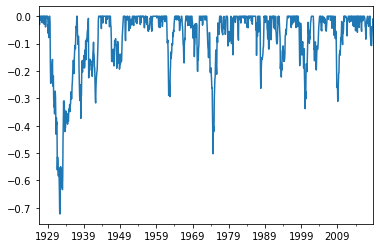

In [49]:
(df_dr['drawdowns']).plot()

In [50]:
cols_of_interest=['Food','Smoke','Coal','Beer','Fin']
erk.var_gaussian_cf_modification(ind[cols_of_interest],modification=True)

Food     0.061207
Smoke    0.080292
Coal     0.047359
Beer     0.033881
Fin      0.075199
dtype: float64

In [51]:
lol = erk.get_ind30_returns()
lol.head()

,Food,Beer,Smoke,Games,Books,Hshld,Clths,Hlth,Chems,Txtls,...,Telcm,Servs,BusEq,Paper,Trans,Whlsl,Rtail,Meals,Fin,Other
1926-07,0.0056,-0.0519,0.0129,0.0293,0.1097,-0.0048,0.0808,0.0177,0.0814,0.0039,...,0.0083,0.0922,0.0206,0.0770,0.0193,-0.2379,0.0007,0.0187,0.0037,0.0520
1926-08,0.0259,0.2703,0.0650,0.0055,0.1001,-0.0358,-0.0251,0.0425,0.0550,0.0814,...,0.0217,0.0202,0.0439,-0.0238,0.0488,0.0539,-0.0075,-0.0013,0.0446,0.0676
1926-09,0.0116,0.0402,0.0126,0.0658,-0.0099,0.0073,-0.0051,0.0069,0.0533,0.0231,...,0.0241,0.0225,0.0019,-0.0554,0.0005,-0.0787,0.0025,-0.0056,-0.0123,-0.0386
1926-10,-0.0306,-0.0331,0.0106,-0.0476,0.0947,-0.0468,0.0012,-0.0057,-0.0476,0.0100,...,-0.0011,-0.0200,-0.0109,-0.0508,-0.0264,-0.1538,-0.0220,-0.0411,-0.0516,-0.0849
1926-11,0.0635,0.0729,0.0455,0.0166,-0.0580,-0.0054,0.0187,0.0542,0.0520,0.0311,...,0.0163,0.0377,0.0364,0.0384,0.0160,0.0467,0.0652,0.0433,0.0224,0.0400


In [8]:
erk.var_gaussian_cf_modification(ind,modification=True).sort_values().tail()

Carry    0.094527
Meals    0.098403
BusEq    0.099377
Games    0.100701
Mines    0.102782
dtype: float64

<AxesSubplot:title={'center':'industry sharpe'}>

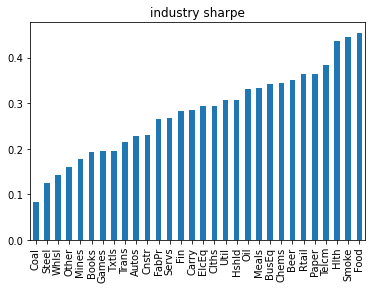

In [6]:
erk.sharpe_ratio(ind,0.03,12).sort_values().plot.bar(title = 'industry sharpe')

<AxesSubplot:title={'center':'industry sharpe'}>

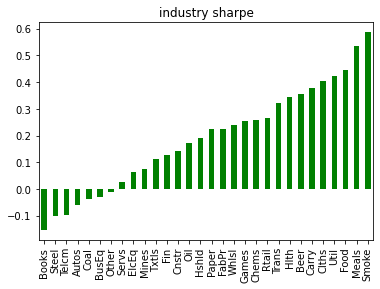

In [7]:
erk.sharpe_ratio(ind['2000':],0.03,12).sort_values().plot.bar(title = 'industry sharpe', color='green')

<AxesSubplot:>

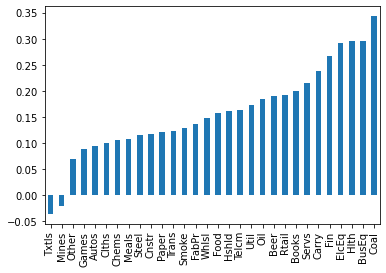

In [7]:
er = erk.annualized_return(ind['1995':'2000'],12)
er.sort_values().plot.bar()

In [8]:
cov = ind['1996':'2000'].cov()

In [9]:
er = erk.annualized_return(ind['1996':'2000'],12)

In [61]:
def portfolio_return(weights,exp_returns):
    '''weights->returns'''
    res = weights.T @ exp_returns
    return res
def portfolio_vol(weights,cov):
    '''weights->volatility'''
    res = (weights.T @ cov @ weights)**0.5
    return res

In [62]:
l = ['Food','Beer','Smoke','Coal']
er[l]

Food     0.116799
Beer     0.141126
Smoke    0.107830
Coal     0.414689
dtype: float64

In [63]:
cov.loc[l,l]

,Food,Beer,Smoke,Coal
Food,0.002609,0.002379,0.002061,0.000027
Beer,0.002379,0.005264,0.001359,0.001728
Smoke,0.002061,0.001359,0.008349,-0.000733
Coal,0.000027,0.001728,-0.000733,0.018641


In [64]:
weights = np.repeat(1/4,4)

In [65]:
weights

array([0.25, 0.25, 0.25, 0.25])

In [66]:
erk.portfolio_return(weights,er[l])

0.19511097196038385

In [67]:
erk.portfolio_vol(weights,cov.loc[l,l])

0.055059195776437045

# 2 Asset frontier


#we create a portfolio for 2 assets

In [10]:
l = ['Games','Fin']

In [11]:
no_points = 20
weights = [np.array([w,1-w]) for w in np.linspace(0,1,no_points)]

In [12]:
weights

[array([0., 1.]),
 array([0.05263158, 0.94736842]),
 array([0.10526316, 0.89473684]),
 array([0.15789474, 0.84210526]),
 array([0.21052632, 0.78947368]),
 array([0.26315789, 0.73684211]),
 array([0.31578947, 0.68421053]),
 array([0.36842105, 0.63157895]),
 array([0.42105263, 0.57894737]),
 array([0.47368421, 0.52631579]),
 array([0.52631579, 0.47368421]),
 array([0.57894737, 0.42105263]),
 array([0.63157895, 0.36842105]),
 array([0.68421053, 0.31578947]),
 array([0.73684211, 0.26315789]),
 array([0.78947368, 0.21052632]),
 array([0.84210526, 0.15789474]),
 array([0.89473684, 0.10526316]),
 array([0.94736842, 0.05263158]),
 array([1., 0.])]

In [13]:
rets_l=[]
vols_l=[]
for w in weights:
    rets = erk.portfolio_return(w,er[l])
    vols = erk.portfolio_vol(w,cov.loc[l,l])
    rets_l.append(rets)
    vols_l.append(vols)
ef =pd.DataFrame({'R':rets_l , 'Vol':vols_l})

<AxesSubplot:xlabel='Vol', ylabel='R'>

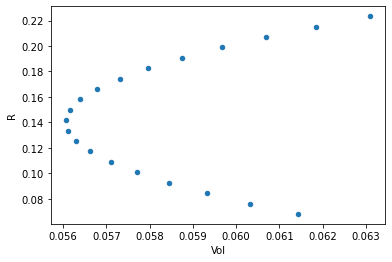

In [27]:
ef.plot.scatter(x='Vol',y='R')

<AxesSubplot:xlabel='Volatility'>

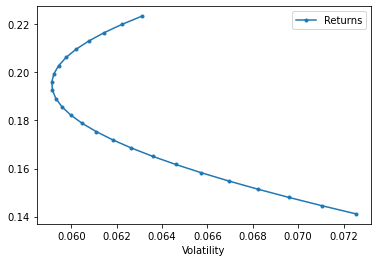

In [14]:
l =['Fin','Beer']
erk.plot_ef2(25,er[l],cov.loc[l,l])

# N-ASSET EFFICIENT FRONTIER

In [1]:
'''def plot_ef2(no_points , exp_ret , cov_matrix):
    import numpy as np
    """plots the n-asset portfolio"""
    weights = minimize_vol()
    returns = [portfolio_return(w,exp_ret) for w in weights]
    volatilities = [portfolio_vol(w,cov_matrix) for w in weights]
    ef = pd.DataFrame({'Returns':returns,'Volatility':volatilities})
    return ef.plot.line(x='Volatility',y='Returns',style='.-')'''

'def plot_ef2(no_points , exp_ret , cov_matrix):\n    import numpy as np\n    """plots the n-asset portfolio"""\n    weights = minimize_vol()\n    returns = [portfolio_return(w,exp_ret) for w in weights]\n    volatilities = [portfolio_vol(w,cov_matrix) for w in weights]\n    ef = pd.DataFrame({\'Returns\':returns,\'Volatility\':volatilities})\n    return ef.plot.line(x=\'Volatility\',y=\'Returns\',style=\'.-\')'

In [74]:
from scipy.optimize import minimize

<AxesSubplot:xlabel='Volatility'>

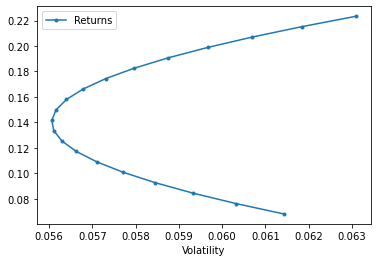

In [21]:
l=['Games','Fin']
erk.plot_ef2(20,er[l],cov.loc[l,l])

In [18]:
def minimize_volatility(target_return,er,cov):
    '''
    from a target return (for ex. the 0.15) to the weight vector , r -> w
    '''
    n = er.shape[0]
    print(n)
    init_guess = np.repeat(1/n,n)
    print(init_guess)
    bounds = ((0.0,1.0),) * n
    return_is_target = {
        'type':'eq' , 
        'args':(er,),
        'fun': lambda weights,er : target_return - erk.portfolio_return(weights,er)
    }
    weights_sum_to1 = {
        'type':'eq',
        'fun':lambda weights : np.sum(weights)-1
    }
    
    'now we run the optimizer'
    results = minimize(portfolio_vol,init_guess,args=(cov,),method='SLSQP',
                       options={'disp':False},
                       constraints=(return_is_target,weights_sum_to1),
                       bounds=bounds
                      )
    return results.x

In [22]:
w15 = erk.minimize_volatility(0.15,er[l],cov.loc[l,l])

In [23]:
erk.portfolio_vol(w15,cov.loc[l,l])

0.056163669406706564

In [82]:
def optimal_weights(no_points,er,cov):
    '''
    i set the target returns here and they convert to optimal weights with the optimizer
    '''
    target_rs = np.linspace(er.min(),er.max(),no_points)
    weights = [minimize_volatility(target_return,er,cov) for target_return in target_rs]
    return weights


def plot_ef(no_points , exp_ret , cov):
    import numpy as np
    """plots the n-asset portfolio"""
    weights = optimal_weights(no_points, er, cov)
    returns = [erk.portfolio_return(w,exp_ret) for w in weights]
    volatilities = [erk.portfolio_vol(w,cov) for w in weights]
    ef = pd.DataFrame({'Returns':returns,'Volatility':volatilities})
    return ef.plot.line(x='Volatility',y='Returns',style='.-')

In [2]:
l=['Smoke','Fin','Games','Coal']
print(no_points)
print(er[l])
print('------------')
print(cov.loc[l,l])
plot_ef(25,er[l],cov.loc[l,l])

NameError: name 'no_points' is not defined

In [3]:
def portfolio_return(weights,exp_returns):
    '''weights->returns'''
    return weights.T @ exp_returns
  
def portfolio_vol(weights,covmat):
    '''weights->volatility'''
    return (weights.T @ covmat @ weights)**0.5

In [ ]:
np.repeat(1/n,n)